In [5]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.ticker import MaxNLocator

In [3]:
def formatFig(xlabel, ylabel, leg, xlim, ylim, loc=1, bbox_to_anchor=None):
    label_font = {'fontname': 'Arial', 'size': 14, 'color': 'black', 'weight': 'bold',
                    'labelpad': 10}
    
    legend = plt.legend(leg, frameon=False,loc=loc, bbox_to_anchor=bbox_to_anchor)
    ax = plt.gca()
    ax.tick_params(direction='in', axis='both', which='major', pad=10)
    
    # Set the rotation and label coordinates for the fraction part
    #ax.yaxis.label.set_rotation(0)
    #ax.yaxis.set_label_coords(-0.19, 0.5)

    # Increase font size and make it bold        
    for item in ([ax.title, ax.xaxis.label, ax.yaxis.label] + ax.get_xticklabels() 
                    + ax.get_yticklabels() + legend.get_texts()):
        item.set_fontsize(14)
        item.set_fontname('Arial')
        item.set_fontweight('bold')
        
    # Remove right and top spines
    ax.spines['right'].set_visible(False)
    ax.spines['top'].set_visible(False)

    ax.set_xlabel(xlabel, **label_font)
    ax.set_ylabel(ylabel, **label_font, rotation=90)
    
    ax.set_ylim(ylim)
    ax.set_xlim(xlim)

    plt.tight_layout()

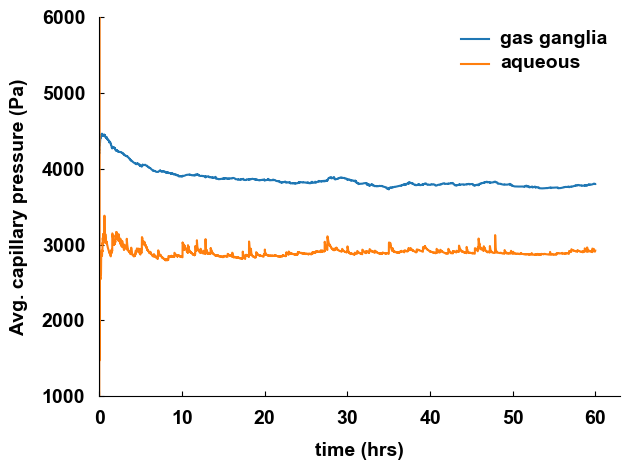

In [7]:
data = np.loadtxt('AvgPc_time_ostRipening_Bent.csv', skiprows=1, delimiter=',')
data = data[:-1]
plt.plot(data[:,1]/3600, data[:,2])
plt.plot(data[:,1]/3600, data[:,4])

formatFig('time (hrs)', 'Avg. capillary pressure (Pa)', ['gas ganglia','aqueous'], [0, None], [1000,6000])
plt.savefig('avgPc_time_ostripening_bent.png', dpi=500)
plt.show()
plt.close()

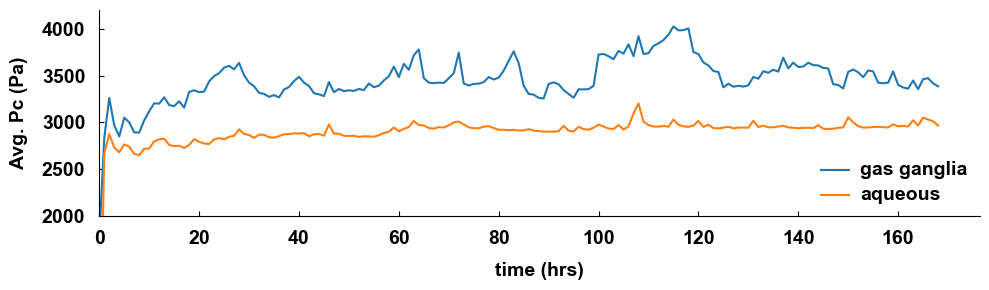

In [8]:
#data = np.loadtxt('AvgPc_time_OstRipening_bent_every_hour.dat', delimiter=',')
data = np.loadtxt('AvgPc_time_volweighted_OstRipening_bent_every_hour.dat', delimiter=',')
plt.figure(figsize=(10, 3))
plt.plot(data[:,0]/3600, data[:,1])
plt.plot(data[:,0]/3600, data[:,2])

formatFig('time (hrs)', 'Avg. Pc (Pa)', ['gas ganglia','aqueous'], [0, None], [2000,4200], 4)
#plt.savefig('avgPc_time_ostripening_bent_hourly.png', dpi=500)
plt.savefig('avgPc_time_volweighted_ostripening_bent_hourly.png', dpi=500)
plt.show()
plt.close()

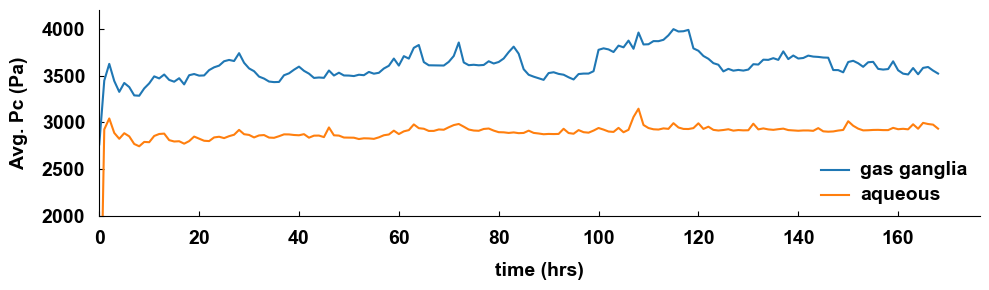

In [9]:
data = np.loadtxt('AvgPc_time_OstRipening_bent_every_hour.dat', delimiter=',')
#data = np.loadtxt('AvgPc_time_volweighted_OstRipening_bent_every_hour.dat', delimiter=',')
plt.figure(figsize=(10, 3))
plt.plot(data[:,0]/3600, data[:,1])
plt.plot(data[:,0]/3600, data[:,2])

formatFig('time (hrs)', 'Avg. Pc (Pa)', ['gas ganglia','aqueous'], [0, None], [2000,4200], 4)
#plt.savefig('avgPc_time_ostripening_bent_hourly.png', dpi=500)
plt.savefig('avgPc_time_ostripening_bent_hourly.png', dpi=500)
plt.show()
plt.close()

In [10]:
def __plotDistribution__(radiusData, weights, fFaz, color, lineWidth, n, 
                             pltLabel='_nolegend_', lineStyle='-', markerStyle=None):
    
        vTotal = np.sum(weights)
        rMax = np.max(radiusData) + 1e-32
        rMin = np.min(radiusData) - 1e-32
        print(rMax, rMin, n)
        drV = (rMax - rMin) / (n - 1)
        Edges = np.zeros(shape=(n, 1), dtype=float)
    
        fr = np.zeros(shape=(n - 1, 1), dtype=float)
        Edges[0] = rMin
        
        tempArray = (radiusData * fFaz)
        for ii in range(n - 1):
            rUpper = rMin + (ii + 1) * drV
            rLower = rMin + (ii) * drV
            Edges[ii + 1] = rUpper
            if ii == n - 2:
                rUpper = np.inf

            temp = ((tempArray >= rLower) & (tempArray < rUpper))
        
            fr[ii] = np.sum(weights[temp])
        
        rV = Edges[:n - 1] + np.diff(Edges, axis=0) / 2
        minrV = min(rV)

        rV = np.insert(rV, 0, 0.0)
        fr = np.insert(fr, 0, 0.0)
        rV = np.append(rV, rV[-1] + drV)
        fr = np.append(fr, 0.0)

        xx = rV #* 1e6
        yy = fr / (vTotal)

        # print(xx, yy)

        # if minrV * 1e6 > 10:
        #     xx[0] = minrV * 1e6 - 0.00001

        # plt.plot(xx, yy, color=color, linestyle=lineStyle, linewidth=lineWidth, 
        #          marker=markerStyle, markersize=6, markerfacecolor='None', 
        #          alpha=1.0, label=pltLabel)
        '''plt.fill_between(x= xx, y1= yy, 
                         #where= (-1 < t)&(t < 1),
                         color=color,
                         alpha= 0.1, label=pltLabel)'''

        #plt.savefig('ddddddddd100.png', dpi=500)

        return xx, yy


In [11]:
rarray = np.loadtxt('radiiArray_bent.dat', delimiter=',')
xx0, yy0 = __plotDistribution__(
                        rarray, 
                        data[0],
                        np.ones(bin_edges.size),
                        'k', 2, num_bins, lineStyle='-',
                        pltLabel='time = 0.0 hrs')

0.000101656 -1e-32 25


ValueError: operands could not be broadcast together with shapes (27329,) (26,) 

In [12]:
data = np.loadtxt('freqDistOstRipening_bent_50bins.dat', delimiter=',')
time = np.linspace(0, 60*3600, 61)
num_bins = 50
rarray = np.loadtxt('radiiArray_bent.dat', delimiter=',')
bin_edges = np.linspace(rarray.min(), rarray.max(), num_bins + 1)*1e6
bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2


xx0, yy0 = __plotDistribution__(
                        bin_edges, 
                        data[0],
                        np.ones(bin_edges.size),
                        'k', 2, num_bins, lineStyle='-',
                        pltLabel='time = 0.0 hrs')

j=0
for i, arr in enumerate(data):
    #if i%10==0 and i!=0:
    if i in [2,4,6,8,10,12,24,36,48,60]:
        j+=1
        leg = ['time = 0.0 hrs']

        xx, yy = __plotDistribution__(
                        bin_edges, 
                        arr,
                        np.ones(bin_edges.size),
                        'k', 2, num_bins, lineStyle='--',
                        pltLabel='time = 0.0 hrs')
        plt.plot(xx0, yy0, color='red')
        plt.plot(xx, yy, '--', color='blue')
        # plt.step(bin_edges, data[0], where='mid', color='red')
        plt.fill_between(xx0, yy0, yy, alpha=0.2, color='red')
        # plt.step(bin_edges, arr, where='post', color='blue')
        plt.fill_between(xx, yy, alpha=0.4, color='blue')
        leg.append(f'time = {time[i]/3600} hrs')
        formatFig('radius (microns)', 'frequency', leg, [0, None], [0,None])
        plt.savefig(f'frequency_time_ostripening_bent_50bins_{j}.png', dpi=500)
        plt.close()
        


0.000101656 -1e-32 50


ValueError: operands could not be broadcast together with shapes (27329,) (51,) 

In [59]:
# frequency distribution by radius
data = np.loadtxt('freqDistOstRipening_bent_every_hour_50bins.dat', delimiter=',')
timeArray = np.loadtxt('timeArrayOstRipening_bent_every_hour.dat', delimiter=',')
num_bins = 50
rarray = np.loadtxt('radiiArray_bent.dat', delimiter=',')
bin_edges = np.linspace(rarray.min(), rarray.max(), num_bins+1)*1e6
bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2
drV = (rarray.max() - rarray.min()) / (num_bins)
rV = bin_edges[:num_bins] + np.diff(bin_edges, axis=0) / 2


def f(weights, drV, rV):
    vTotal = np.sum(weights)
    rV = np.insert(rV, 0, 0.0)
    fr = np.insert(weights, 0, 0.0)
    rV = np.append(rV, rV[-1] + drV)
    #fr = np.append(fr, 0.0)

    xx = rV
    yy = fr / (vTotal)
    return xx, yy


xx0, yy0 = f(data[0], drV, rV)
for i, arr in enumerate(data[1:]):
    leg = ['time = 0.0 hrs']
    xx, yy = f(arr, drV, rV)
    plt.plot(xx0, yy0, color='red')
    plt.plot(xx, yy, '--', color='blue')
    #plt.fill_between(xx0, yy0, yy, alpha=0.2, color='red')
    #plt.fill_between(xx, yy, alpha=0.4, color='blue')
    leg.append(f'time = {round(timeArray[i+1]/3600,1)} hrs')
    formatFig('radius (microns)', 'frequency', leg, [0, None], [0,None])
    plt.savefig(f'frequency_time_ostripening_bent_50bins_{i+1}.png', dpi=500)
    plt.close()



In [78]:
# cumulative frequency distribution by volume
data = np.loadtxt('volDistOstRipening_bent_every_hour_50bins.dat', delimiter=',')
timeArray = np.loadtxt('timeArrayOstRipening_bent_every_hour.dat', delimiter=',')
num_bins = 50
varray = np.loadtxt('volarray_bent.dat', delimiter=',')
bin_edges = np.linspace(varray.min(), varray.max(), num_bins+1)#*1e6
bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2
drV = (varray.max() - varray.min()) / (num_bins)
rV = bin_edges[:num_bins] + np.diff(bin_edges, axis=0) / 2


def f(weights, drV, rV):
    vTotal = np.sum(weights)
    rV = np.insert(rV, 0, 0.0)
    fr = np.insert(weights, 0, 0.0)
    rV = np.append(rV, rV[-1] + drV)
    #fr = np.append(fr, 0.0)

    xx = rV
    # yy = np.cumsum(fr / (vTotal))
    yy = np.cumsum(fr)
    return xx, yy


xx0, yy0 = f(data[0], drV, rV)
for i, arr in enumerate(data[1:]):
    leg = ['time = 0.0 hrs']
    xx, yy = f(arr, drV, rV)
    plt.plot(xx0, yy0, color='red')
    plt.plot(xx, yy, '--', color='blue')
    #plt.fill_between(xx0, yy0, yy, alpha=0.2, color='red')
    #plt.fill_between(xx, yy, alpha=0.4, color='blue')
    leg.append(f'time = {round(timeArray[i+1]/3600,1)} hrs')
    formatFig(r'volume ($\mathbf{m^3}$)', r'Cum. volume ($\mathbf{m^3}$)', leg, [0, None], [0,2.61e-9], 0)
    plt.savefig(f'cumvol_time_ostripening_bent_50bins_{i+1}.png', dpi=500)
    plt.close()
    # if i>1:
    #     break

    

In [74]:
# cumulative frequency distribution by volume
data = np.loadtxt('volDistOstRipening_bent_every_hour_50bins_1.dat', delimiter=',')
timeArray = np.loadtxt('timeArrayOstRipening_bent_every_hour.dat', delimiter=',')
num_bins = 50
varray = np.loadtxt('volarray_bent.dat', delimiter=',')
bin_edges = np.linspace(data.min(), data.max(), num_bins+1)#*1e6
bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2
drV = (data.max() - data.min()) / (num_bins)
rV = bin_edges[:num_bins] + np.diff(bin_edges, axis=0) / 2
bin_indices = np.digitize(data[0], bin_edges, right=True)
yy0 = np.bincount(bin_indices, data[0], num_bins+1)/data[0].sum()

def f(weights, drV, rV):
    vTotal = np.sum(weights)
    rV = np.insert(rV, 0, 0.0)
    fr = np.insert(weights, 0, 0.0)
    rV = np.append(rV, rV[-1] + drV)
    #fr = np.append(fr, 0.0)

    xx = rV
    # yy = np.cumsum(fr / (vTotal))
    yy = np.cumsum(fr)
    return xx, yy

print(bin_edges)
#xx0, yy0 = f(data[0], drV, rV)
for i, arr in enumerate(data[1:]):
    leg = ['time = 0.0 hrs']
    bin_indices = np.digitize(arr, bin_edges, right=True)
    yy = np.bincount(bin_indices, arr, num_bins+1)/arr.sum()
    #xx, yy = f(arr, drV, rV)
    
    #plt.plot(bin_edges*1e6, np.cumsum(yy0), color='red')
    #plt.plot(bin_edges*1e6, np.cumsum(yy), '--', color='blue')
    plt.fill_between(bin_edges*1e18, np.cumsum(yy0), 0.0, color='red', alpha=0.4)
    plt.fill_between(bin_edges*1e18, np.cumsum(yy), 0.0, facecolor='none', edgecolor='blue', hatch='//')
    leg.append(f'time = {round(timeArray[i+1]/3600,1)} hrs')
    formatFig(r'volume ($\mathbf{\mu m^3}$)', r'Volume fraction', leg, 
              [0, None], [0,None], 2)
    plt.savefig(f'cumvol_time_ostripening_bent_50bins_{i+1}.png', dpi=500)
    plt.close()
    # if i>5:
    #     break

[0.0000000e+00 1.2709920e-11 2.5419840e-11 3.8129760e-11 5.0839680e-11
 6.3549600e-11 7.6259520e-11 8.8969440e-11 1.0167936e-10 1.1438928e-10
 1.2709920e-10 1.3980912e-10 1.5251904e-10 1.6522896e-10 1.7793888e-10
 1.9064880e-10 2.0335872e-10 2.1606864e-10 2.2877856e-10 2.4148848e-10
 2.5419840e-10 2.6690832e-10 2.7961824e-10 2.9232816e-10 3.0503808e-10
 3.1774800e-10 3.3045792e-10 3.4316784e-10 3.5587776e-10 3.6858768e-10
 3.8129760e-10 3.9400752e-10 4.0671744e-10 4.1942736e-10 4.3213728e-10
 4.4484720e-10 4.5755712e-10 4.7026704e-10 4.8297696e-10 4.9568688e-10
 5.0839680e-10 5.2110672e-10 5.3381664e-10 5.4652656e-10 5.5923648e-10
 5.7194640e-10 5.8465632e-10 5.9736624e-10 6.1007616e-10 6.2278608e-10
 6.3549600e-10]


In [61]:
np.bincount(xx, arr, num_bins+1)/arr.sum()

array([0.        , 0.        , 0.00779249, 0.01319131, 0.054542  ,
       0.02720845, 0.06116597, 0.03782821, 0.08186383, 0.        ,
       0.05009692, 0.05960478, 0.        , 0.0679754 , 0.        ,
       0.07825377, 0.        , 0.        , 0.09481859, 0.        ,
       0.10577382, 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.25988446, 0.        , 0.        ,
       0.        ])

In [14]:
# cumulative volume distribution
import csv


def f(weights, drV, rV):
    #print('weight:  ', weights, weights.size)
    vTotal = np.sum(weights)
    rV = np.insert(rV, 0, 0.0)
    fr = np.insert(weights, 0, 0.0)
    rV = np.append(rV, rV[-1] + drV)
    #fr = np.append(fr, 0.0)
    xx = rV
    # yy = np.cumsum(fr / (vTotal))
    yy = np.cumsum(fr)
    #yy = fr
    return xx, yy

num_bins=25
timeArray = np.loadtxt('timeArrayOstRipening_bent_every_hour.dat', delimiter=',')
varray = np.loadtxt('volarray_bent.dat', delimiter=',')*1e6
volTotal = varray.sum()
bin_edges = np.linspace(varray.min(), varray.max(), num_bins+1)
bin_indices = np.digitize(varray, bin_edges, right=True)
xx_e = bin_edges
yy_e = np.bincount(bin_indices, varray, minlength=num_bins+1)

col_index = np.arange(27329)
data = np.loadtxt('volDistOstRipening_bent_every_hour_25bins.dat', delimiter=',')*1e6
maxVol = data.max()
bin_edges = np.linspace(0.0, maxVol, num_bins + 1)
bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2
drV = maxVol/ (num_bins)
rV = bin_edges[:num_bins] + np.diff(bin_edges, axis=0) / 2

xx0, yy0 = f(data[0], drV, rV)
for i, arr in enumerate(data[1:]):
    # plt.plot(xx_e, yy_e, color='grey')
    # plt.fill_between(xx_e, yy_e, 0.0, color='grey', alpha=0.4)
    leg = ['time = 0.0 hrs']
    xx, yy = f(arr, drV, rV)
        
    plt.bar(xx0[:-1],  yy0[:-1]/data[0].sum(),  width=np.diff(xx0), 
        facecolor='none', edgecolor='blue', hatch='//', align='center')

    plt.bar(xx[:-1],  yy[:-1]/data[0].sum(),  width=np.diff(xx), color='red', alpha=0.4
        #facecolor='none', edgecolor='none', align='edge'
        )    

   
    #plt.xscale('log')
    #plt.yscale('log')
    leg.append(f'time = {round(timeArray[i+1]/3600,1)} hrs')
    formatFig(r'volume ($\mathbf{\mu m^3}$)', r'Fraction', leg, [0, None], [0,None], 0)
    plt.savefig(f'cumvol_time_ostripening_bent_25bins_{i+1}.png', dpi=500)
    plt.close()
    if i>10:
        break

In [51]:
# cumulative volume distribution
import csv


def f(weights, drV, rV):
    #print('weight:  ', weights, weights.size)
    vTotal = np.sum(weights)
    rV = np.insert(rV, 0, 0.0)
    fr = np.insert(weights, 0, 0.0)
    rV = np.append(rV, rV[-1] + drV)
    #fr = np.append(fr, 0.0)
    xx = rV
    # yy = np.cumsum(fr / (vTotal))
    #yy = np.cumsum(fr)
    yy = fr
    return xx, yy

num_bins=50
timeArray = np.loadtxt('timeArrayOstRipening_bent_every_hour.dat', delimiter=',')
varray = np.loadtxt('volarray_bent.dat', delimiter=',')*1e6
volTotal = varray.sum()
rarray = np.loadtxt('radiiArray_bent.dat', delimiter=',')
bin_edges = np.linspace(rarray.min(), rarray.max(), num_bins+1)
bin_indices = np.digitize(rarray, bin_edges, right=True)

col_index = np.arange(27329)
clustID = np.loadtxt('clustID_OstRipening_bent_every_hour.dat', delimiter=',')
yy0 = np.bincount(bin_indices[clustID[0]>0], varray[clustID[0]>=0], num_bins+1)/volTotal
print(yy0)
for i, arr in enumerate(clustID):
    plt.fill_between(bin_edges*1e6, np.cumsum(yy0), 0.0, 
                     facecolor='none', edgecolor='blue',hatch='//', alpha=1.0)
    leg = ['time = 0.0 hrs']
    yy = np.bincount(bin_indices[clustID[i]>0], varray[clustID[i]>=0], num_bins+1)/volTotal
    plt.fill_between(bin_edges*1e6, np.cumsum(yy), 0, color='red', alpha=0.2)
   
    leg.append(f'time = {round(timeArray[i+1]/3600,1)} hrs')
    formatFig(r'volume ($\mathbf{\mu m^3}$)', r'Fraction', leg, [0, None], [0,None], 2)
    plt.savefig(f'cumvol_time_ostripening_bent_25bins_{i+1}.png', dpi=500)
    plt.close()
    if i>5:
        break

[0.00000000e+00 1.34133673e-05 1.14052923e-04 1.22978985e-03
 3.41840191e-03 6.15518205e-03 8.52223202e-03 1.36534160e-02
 1.70125837e-02 1.85911626e-02 1.98179794e-02 1.93315979e-02
 1.99789675e-02 2.07336166e-02 1.75585648e-02 1.52286061e-02
 1.48170405e-02 1.63654406e-02 1.54219643e-02 1.66931091e-02
 1.41448186e-02 1.14502712e-02 1.38673461e-02 1.80886814e-02
 8.89337225e-03 1.27668807e-02 9.76833384e-03 7.68482356e-03
 6.74306754e-03 5.54957844e-03 6.31131534e-03 6.59313022e-03
 4.34209328e-03 4.44443434e-03 5.76845987e-03 3.03600755e-03
 1.19264302e-03 4.52089713e-03 5.40241044e-03 3.10667641e-03
 3.80870753e-03 1.10727092e-03 1.74089804e-03 3.63561433e-03
 0.00000000e+00 2.08295983e-03 0.00000000e+00 2.90870785e-03
 4.65004446e-03 0.00000000e+00 3.31408621e-03]


In [6]:
def formatFig1(ax, xlabel, ylabel, xlim, ylim):
    label_font = {'fontname': 'Arial', 'size': 14, 'color': 'black', 'weight': 'bold',
                    'labelpad': 10}
    
    ax.tick_params(direction='in', axis='both', which='major', pad=10)
    
    # Increase font size and make it bold        
    for item in ([ax.title, ax.xaxis.label, ax.yaxis.label] + ax.get_xticklabels() 
                    + ax.get_yticklabels()):
        item.set_fontsize(14)
        item.set_fontname('Arial')
        item.set_fontweight('bold')
        
    # Remove right and top spines
    ax.spines['right'].set_visible(False)
    ax.spines['top'].set_visible(False)

    ax.set_xlabel(xlabel, **label_font)
    ax.set_ylabel(ylabel, **label_font, rotation=90)
    
    ax.set_ylim(ylim)
    ax.set_xlim(xlim)

    plt.tight_layout()

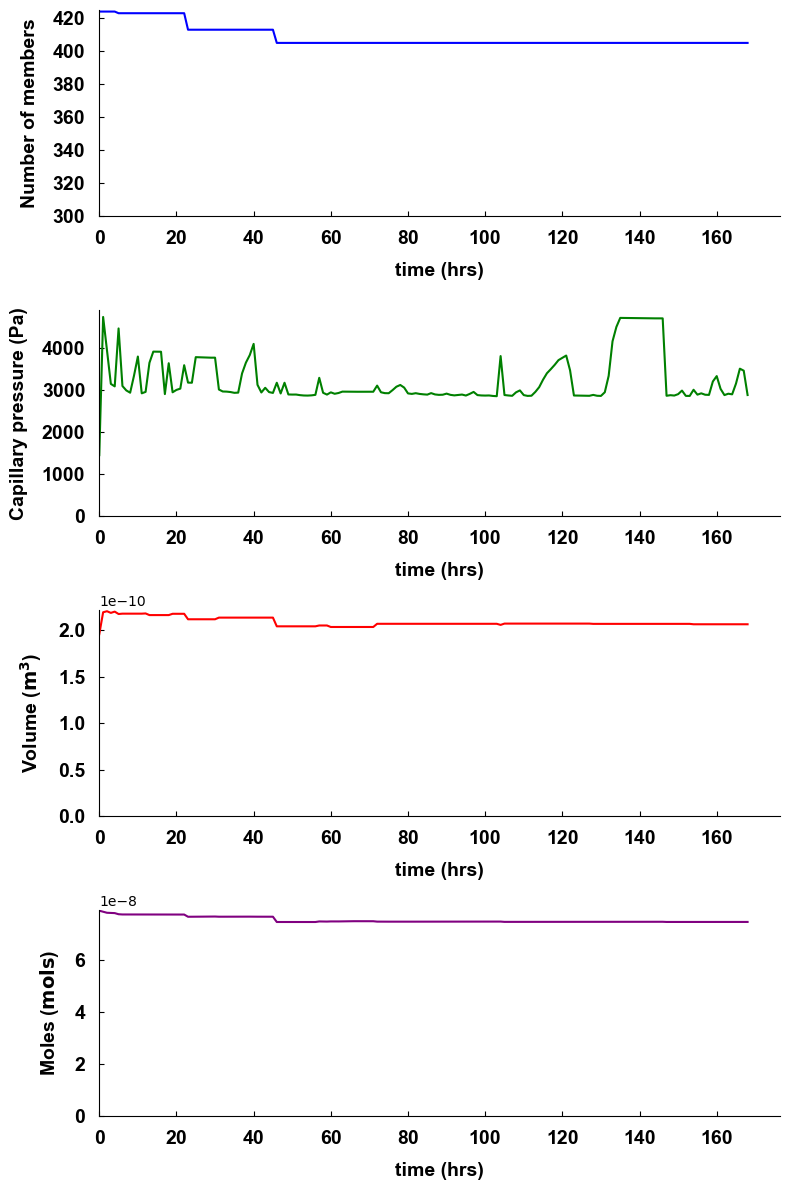

In [108]:
# case study : pore 1
data = pd.read_csv('pore_1_case_study_OstRipening_bent_every_hour.dat', 
                   header=None, delimiter=',')
timeArray = np.loadtxt('timeArrayOstRipening_bent_every_hour.dat', delimiter=',')/3600

# Create 4 subplots in a single column
fig, axes = plt.subplots(4, 1, figsize=(8, 12))

# Plot data on each subplot
axes[0].plot(timeArray, data[1], color="blue")
formatFig1(axes[0], 'time (hrs)', r'Number of members', [0, None], [300, None])

axes[1].plot(timeArray, data[2], label="Capillary pressure", color="green")
formatFig1(axes[1], 'time (hrs)', r'Capillary pressure (Pa)', [0, None], [0, None])

axes[2].plot(timeArray, data[3], label="volume", color="red")
formatFig1(axes[2], 'time (hrs)', r'Volume ($\mathbf{m^3}$)', [0, None], [0, None])

axes[3].plot(timeArray, data[4], label="moles", color="purple")
formatFig1(axes[3], 'time (hrs)', r'Moles ($\mathbf{mols}$)',  [0, None], [0, None])

# Show the plot
plt.savefig(f'case_study_pore_1_ostripening_bent.png', dpi=500)
plt.show()



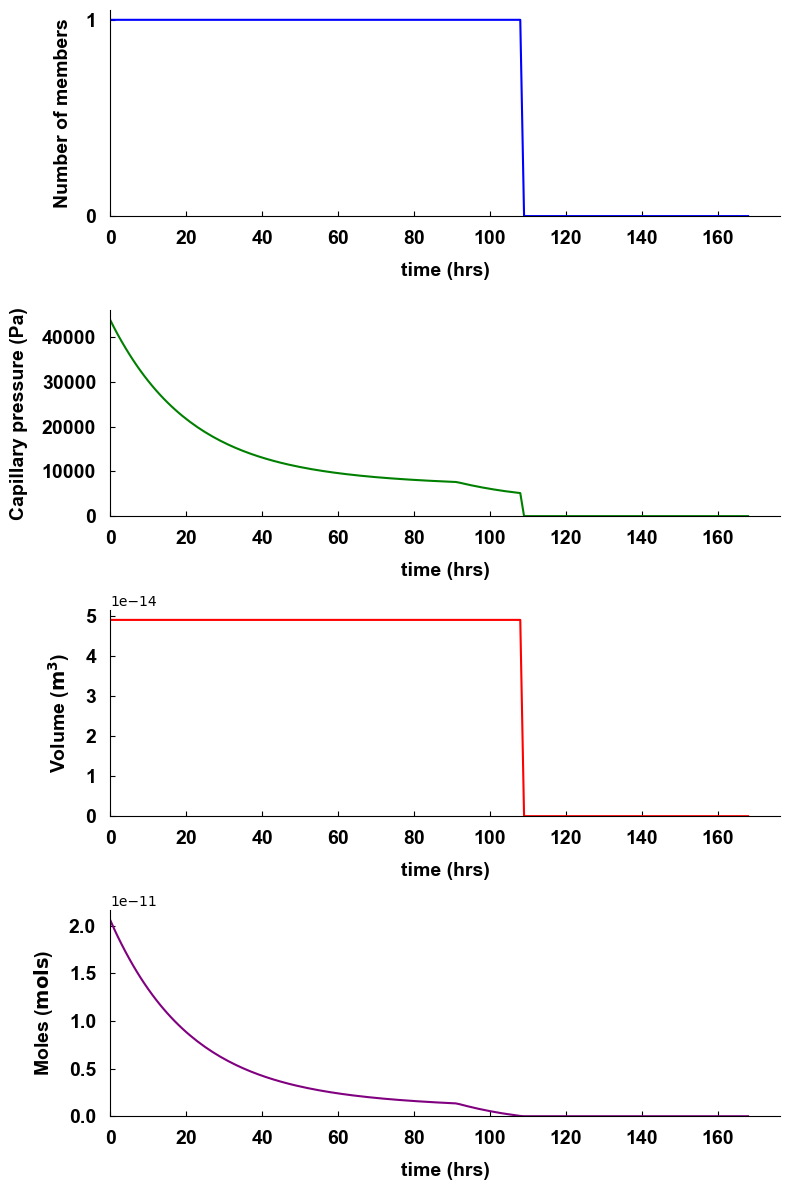

In [113]:
# case study : pore 6243
data = pd.read_csv('pore_6243_case_study_OstRipening_bent_every_hour.dat', 
                   header=None, delimiter=',')
timeArray = np.loadtxt('timeArrayOstRipening_bent_every_hour.dat', delimiter=',')/3600

# Create 4 subplots in a single column
fig, axes = plt.subplots(4, 1, figsize=(8, 12))

# Plot data on each subplot
axes[0].plot(timeArray, data[1], color="blue")
axes[0].yaxis.set_major_locator(MaxNLocator(integer=True))
formatFig1(axes[0], 'time (hrs)', r'Number of members', [0, None], [0, None])


axes[1].plot(timeArray, data[2], label="Capillary pressure", color="green")
formatFig1(axes[1], 'time (hrs)', r'Capillary pressure (Pa)', [0, None], [0, None])

axes[2].plot(timeArray, data[3], label="volume", color="red")
formatFig1(axes[2], 'time (hrs)', r'Volume ($\mathbf{m^3}$)', [0, None], [0, None])

axes[3].plot(timeArray, data[4], label="moles", color="purple")
formatFig1(axes[3], 'time (hrs)', r'Moles ($\mathbf{mols}$)',  [0, None], [0, None])

# Show the plot
plt.savefig(f'case_study_pore_6243_ostripening_bent.png', dpi=500)
plt.show()

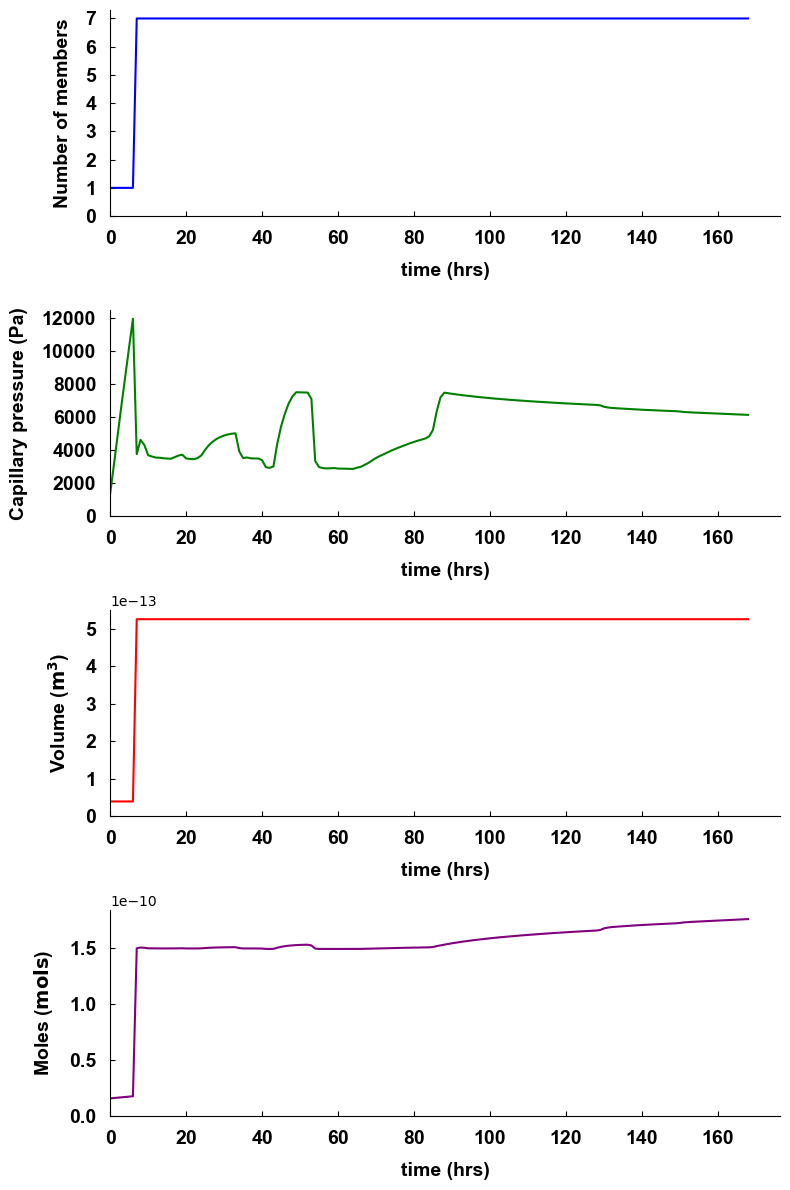

In [110]:
# case study : pore 8421
data = pd.read_csv('pore_8421_case_study_OstRipening_bent_every_hour.dat', 
                   header=None, delimiter=',')
timeArray = np.loadtxt('timeArrayOstRipening_bent_every_hour.dat', delimiter=',')/3600

# Create 4 subplots in a single column
fig, axes = plt.subplots(4, 1, figsize=(8, 12))

# Plot data on each subplot
axes[0].plot(timeArray, data[1], color="blue")
axes[0].yaxis.set_major_locator(MaxNLocator(integer=True))
formatFig1(axes[0], 'time (hrs)', r'Number of members', [0, None], [0, None])


axes[1].plot(timeArray, data[2], label="Capillary pressure", color="green")
formatFig1(axes[1], 'time (hrs)', r'Capillary pressure (Pa)', [0, None], [0, None])

axes[2].plot(timeArray, data[3], label="volume", color="red")
formatFig1(axes[2], 'time (hrs)', r'Volume ($\mathbf{m^3}$)', [0, None], [0, None])

axes[3].plot(timeArray, data[4], label="moles", color="purple")
formatFig1(axes[3], 'time (hrs)', r'Moles ($\mathbf{mols}$)',  [0, None], [0, None])

# Show the plot
plt.savefig(f'case_study_pore_8421_ostripening_bent.png', dpi=500)
plt.show()

(62886, 2)
[     0.         0.         0.    ... 604780.218 604790.221 604800.225]


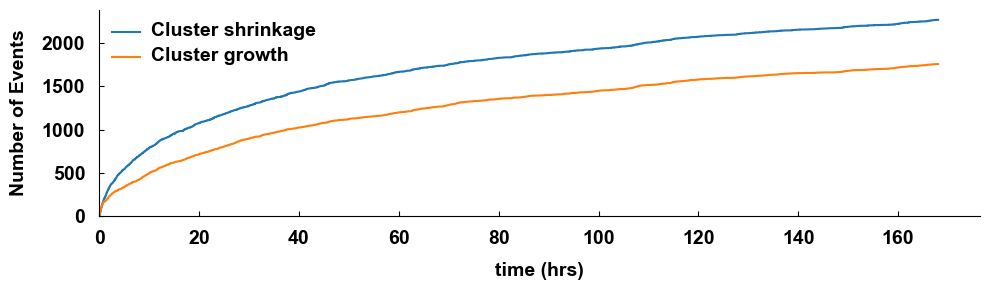

[[   0    0]
 [   0    1]
 [   1    1]
 ...
 [2269 1758]
 [2269 1758]
 [2269 1758]]


In [147]:
data = np.loadtxt('numberEventsOstRipening_bent.dat',dtype=int, delimiter=',')
print(data.shape)
timeArray = np.genfromtxt('timeArrayOstRipening_bent.dat', delimiter=',', invalid_raise=False)
timeArray = np.nan_to_num(timeArray)[:-1]
print(timeArray)
plt.figure(figsize=(10, 3))
plt.plot(timeArray/3600, data[:,0])
plt.plot(timeArray/3600, data[:,1])

formatFig('time (hrs)', 'Number of Events', ['Cluster shrinkage','Cluster growth'], [0, None], [0,None], 0)
plt.savefig('numEvents_time_ostripening_bent.png', dpi=500)
plt.show()
plt.close()
print(data)

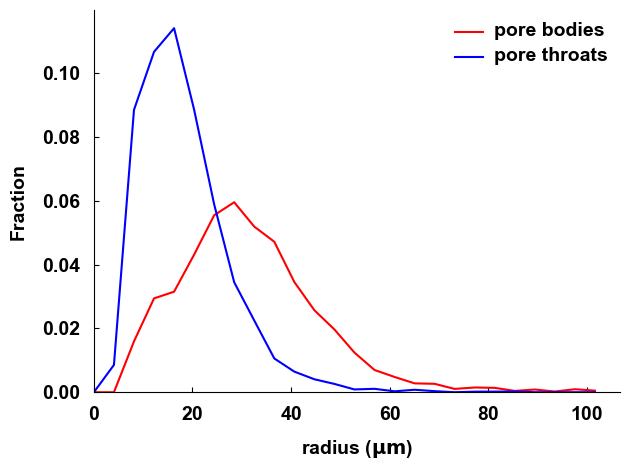

In [86]:
num_bins = 25

rarray = np.loadtxt('radiiArray_bent.dat', delimiter=',')
bin_edges = np.linspace(rarray.min(), rarray.max(), num_bins+1)
bin_indices = np.digitize(rarray, bin_edges, right=True)


rarrayP = rarray[1:8223]
# bin_edges = np.linspace(rarrayP.min(), rarrayP.max(), num_bins+1)
# bin_indices = np.digitize(rarrayP, bin_edges, right=True)
yyP = np.bincount(bin_indices[1:8223], rarrayP, num_bins+1)/rarray.sum()
#plt.fill_between(bin_edges*1e6, yyP, 0.0, color='red', alpha=0.4)
plt.plot(bin_edges*1e6, yyP, color='red')


rarrayT = rarray[8223:-1]
# bin_edges = np.linspace(rarrayT.min(), rarrayT.max(), num_bins+1)
# bin_indices = np.digitize(rarrayT, bin_edges, right=True)
yyT = np.bincount(bin_indices[8223:-1], rarrayT, num_bins+1)/rarray.sum()
#plt.fill_between(bin_edges*1e6, yyT, 0.0, color='blue', alpha=0.4)
plt.plot(bin_edges*1e6, yyT, color='blue')


# leg = ['time = 0.0 hrs']
# bin_indices = np.digitize(arr, bin_edges, right=True)
# yy = np.bincount(bin_indices, arr, num_bins+1)/arr.sum()
# #xx, yy = f(arr, drV, rV)

# #plt.plot(bin_edges*1e6, np.cumsum(yy0), color='red')
# #plt.plot(bin_edges*1e6, np.cumsum(yy), '--', color='blue')
# plt.fill_between(bin_edges*1e18, np.cumsum(yy0), 0.0, color='red', alpha=0.4)
# plt.fill_between(bin_edges*1e18, np.cumsum(yy), 0.0, facecolor='none', edgecolor='blue', hatch='//')
# leg.append(f'time = {round(timeArray[i+1]/3600,1)} hrs')
leg = ['pore bodies', 'pore throats']
formatFig(r'radius ($\mathbf{\mu m}$)', r'Fraction', leg, 
            [0, None], [0,None], 1)
#plt.show()
plt.savefig(f'bent_pore_throat_radii_distributiom.png', dpi=500)
#plt.close()


In [1]:
import numpy as np
fluid_with_trapping_drainage = np.loadtxt(
    'bent_fluid_perc_with_trapping_after_drainage.dat', delimiter=',')
fluid_without_trapping_drainage = np.loadtxt(
    'bent_fluid_perc_without_trapping_after_drainage.dat', delimiter=',')
fluid_with_trapping_imbibition = np.loadtxt(
    'bent_fluid_perc_with_trapping_after_imbibition.dat', delimiter=',')
fluid_without_trapping_imbibition = np.loadtxt(
    'bent_fluid_perc_without_trapping_after_imbibition.dat', delimiter=',')

with_trapping_drainage = np.where(fluid_with_trapping_drainage)
without_trapping_drainage = np.where(fluid_without_trapping_drainage)
arr_growth = np.setdiff1d(without_trapping_drainage, with_trapping_drainage)
with_trapping_imbibition = np.where(fluid_with_trapping_imbibition==0)
without_trapping_imbibition = np.where(fluid_without_trapping_imbibition==0)
arr_shrink = np.setdiff1d(without_trapping_imbibition, with_trapping_imbibition)
print(arr_growth)
print(arr_shrink.size)


[ 4069  5373  5538  5583  5645  5778  5824  5862  5987  5989  5997  6052
  6140  6173  6242  6328  6368  6381  6432  6555  6629  6789  6798  6811
  6833  6835  6850  6858  6883  6890  6927  6941  6990  7091  7118  7135
  7165  7179  7219  7253  7326  7329  7351  7358  7422  7431  7471  7502
  7506  7527  7540  7568  7572  7581  7604  7606  7666  7693  7701  7715
  7735  7763  7804  7832  7867  7909  7944  8027  8140  8143  8153  8158
  8197 20107]
2927


In [18]:
1093/2927, 9*24*3600


(0.3734198838401093, 777600)

In [ ]:
from matplotlib import pyplot as plt
import os
import numpy as np

os.makedirs("./scatterplot", exist_ok=True)
clustPc = np.loadtxt('clustPcOstRipening_bent_new.dat',delimiter=',')
clustVol = np.loadtxt('clustVolOstRipening_bent_new.dat',delimiter=',')
clustID = np.loadtxt('clustIDOstRipening_bent_new.dat',delimiter=',', dtype=int)
timeArray = np.genfromtxt('timeArrayOstRipening_bent_new.dat',delimiter=',', dtype=float)

# select clusters whose membership did not change
selectedIDS = []
for c in range(clustVol.shape[1]):
    try:
        if ((clustVol[0,c] != 0.0) or (clustVol[-1,c] != 0.0)) and\
            ((clustVol[0,c] != clustVol[-1,c])) and\
            np.array_equal(np.where(clustID[0]==c)[0],np.where(clustID[-1]==c)[0]):
            selectedIDS.append(c)
    except:
        pass
selectedIDS = np.array(selectedIDS)



for i, t in enumerate(3600*24*np.arange(8)):
    c = np.argmin(np.abs(timeArray[:-1]-t))
    
    selectedIDS0 = selectedIDS[clustVol[c, selectedIDS]==clustVol[0, selectedIDS]]
    selectedIDS1 = selectedIDS[clustVol[c, selectedIDS]>clustVol[0, selectedIDS]]
    selectedIDS2 = selectedIDS[clustVol[c, selectedIDS]<clustVol[0, selectedIDS]]
    plt.scatter(clustVol[c, selectedIDS0], clustPc[c, selectedIDS0],
                alpha=0.7,
                edgecolors='blue')
    plt.scatter(clustVol[c, selectedIDS2], clustPc[c, selectedIDS2],
                alpha=0.7,
                facecolor='none',
                edgecolors='red',
                marker='^')
    plt.scatter(clustVol[c, selectedIDS1], clustPc[c, selectedIDS1],
                alpha=0.7,
                facecolor='none',
                edgecolors='green',
                marker='s')
        
    xlabel = r'Cluster volume ($m^3$)'
    ylabel = 'Capillary pressure (Pa)'
    xlim = [1e-16, 3e-10]
    ylim = [0, 45000]
    plt.xscale('log')
    plt.text(xlim[1]*0.1, ylim[1]*0.9, s=f'{i} days', fontweight='bold')
    leg = []
    formatFig(xlabel, ylabel, leg, xlim, ylim, loc=1, bbox_to_anchor=None)
    plt.savefig(f'./scatterplot/scatterplot_pc_vol_new_{i}_days.png', dpi=500)
    plt.close()
    



/tmp/ipykernel_21713/2394643629.py:17: DeprecationWarning: elementwise comparison failed; this will raise an error in the future.
  all(np.where(clustID[0]==c)[0]==np.where(clustID[-1]==c)[0]):


In [4]:
from matplotlib import pyplot as plt
import os
import numpy as np

os.makedirs("./scatterplot", exist_ok=True)
clustPc = np.loadtxt('clustPcOstRipening_bent_new.dat',delimiter=',')
clustVol = np.loadtxt('clustVolOstRipening_bent_new.dat',delimiter=',')
clustID = np.loadtxt('clustIDOstRipening_bent_new.dat',delimiter=',', dtype=int)
timeArray = np.genfromtxt('timeArrayOstRipening_bent_new.dat',delimiter=',', dtype=float)

for i, t in enumerate(3600*24*np.arange(8)):
    c = np.argmin(np.abs(timeArray[:-1]-t))
    selectedIDS = np.where(clustVol[c]>0.0)[0]
    plt.scatter(clustVol[c, selectedIDS], clustPc[c, selectedIDS],
                alpha=0.7,
                edgecolors='blue')
        
    xlabel = r'Cluster volume ($m^3$)'
    ylabel = 'Capillary pressure (Pa)'
    xlim = [1e-16, 3e-10]
    ylim = [0, 45000]
    plt.xscale('log')
    plt.text(xlim[1]*0.1, ylim[1]*0.9, s=f'{i} days', fontweight='bold')
    leg = []
    formatFig(xlabel, ylabel, leg, xlim, ylim, loc=1, bbox_to_anchor=None)
    plt.savefig(f'./scatterplot/scatterplot_pc_vol_all_{i}_days.png', dpi=500)
    plt.close()

In [ ]:
dissolvedMoles = np.loadtxt('dissolvedMolesOstRipening_bent_new.dat',delimiter=',')
elemVol = np.loadtxt('volarray_bent.dat',delimiter=',')
H = 6.9e-6

avgGasPc = np.zeros(clustPc.shape[0])
avgAqueousPc = np.zeros(clustPc.shape[0])
for i, pc in enumerate(clustPc):
    avgGasPc[i] = pc[clustVol[i]!=0.0].mean()
    cond = (clustID[i]<0)&(elemVol!=0.0)
    aqueousPc = dissolvedMoles[i][cond]/elemVol[cond]/H
    avgAqueousPc[i] = aqueousPc.mean()

plt.plot(timeArray[:-1]/3600, avgGasPc, 'b')
plt.plot(timeArray[:-1]/3600, avgAqueousPc, 'r')

xlabel = r'Time ($hrs$)'
ylabel = 'Capillary pressure (Pa)'
xlim = [0, None]
ylim = [None, 4500]
#plt.xscale('log')
#plt.text(xlim[1]*0.1, ylim[1]*0.9, s=f'{i} days', fontweight='bold')
leg = ['Gas clusters', 'Aqueous']
formatFig(xlabel, ylabel, leg, xlim, ylim, loc=1, bbox_to_anchor=None)
plt.savefig(f'./scatterplot/avgPc_time_OstRipening_bent_new.png', dpi=500)
plt.close()


In [ ]:
satList = np.loadtxt('saturation_every_day_OstRipening_bent_new.dat', delimiter=',')
leg = []
markerList = ['s', '^', 'd', 'o', 'v', 'D', 'p']
for i, t in enumerate(3600*24*np.arange(7)):
    c = np.argmin(np.abs(timeArray[:-1]-t))
    plt.scatter(satList[i], avgGasPc[c], marker=markerList[i])
    leg.append(f'{i} days')

xlabel = r'$S_w$'
ylabel = 'Capillary pressure (Pa)'
xlim = [0.6, 0.7]
ylim = [None, 4500]
formatFig(xlabel, ylabel, leg, xlim, ylim, loc=1, bbox_to_anchor=None)
plt.savefig(f'./scatterplot/avgPc_sat_OstRipening_bent_new.png', dpi=500)
plt.close()

: 

In [26]:
import csv
import pandas as pd
timeArray = np.genfromtxt('timeArrayOstRipening_bent.dat', delimiter=',', invalid_raise=False)
timeArray = np.nan_to_num(timeArray)
with open('clustPc_OstRipening_bent_every_hour.dat', 'r') as filePc,\
    open('clustVol_OstRipening_bent_every_hour.dat', 'r') as fileVol:
        clustPc = csv.reader(filePc)
        clustVol = csv.reader(fileVol)
        for c, (rowPc, rowVol) in enumerate(zip(clustPc, clustVol)):
            if c%24==0:
                rowPc = np.array([*map(float, rowPc)])
                rowVol = np.array([*map(float, rowVol)])
                selectedIDS = np.where(rowVol>0.0)[0]
                plt.scatter(rowVol[selectedIDS], rowPc[selectedIDS],
                            alpha=0.7,
                            edgecolors='blue')
                    
                xlabel = r'Cluster volume ($m^3$)'
                ylabel = 'Capillary pressure (Pa)'
                xlim = [1e-16, 5e-10]
                ylim = [0, 45000]
                plt.xscale('log')
                plt.text(xlim[1]*0.1, ylim[1]*0.9, s=f'{c//24} days', fontweight='bold')
                leg = []
                formatFig(xlabel, ylabel, leg, xlim, ylim, loc=1, bbox_to_anchor=None)
                plt.savefig(f'./scatterplot/scatterplot_pc_vol_old_{c//24}_days.png', dpi=500)
                plt.close()


In [ ]:
dissolvedMoles = np.loadtxt('dissolvedMoles_OstRipening_bent_every_hour.dat',delimiter=',')
elemVol = np.loadtxt('volarray_bent.dat',delimiter=',')
clustID = np.loadtxt('clustID_OstRipening_bent_every_hour.dat',delimiter=',', dtype=int)
timeArray = np.arange(dissolvedMoles.shape[0])
H = 6.9e-6

avgGasPc = np.zeros(dissolvedMoles.shape[0])
avgAqueousPc = np.zeros(dissolvedMoles.shape[0])
with open('clustPc_OstRipening_bent_every_hour.dat', 'r') as filePc,\
    open('clustVol_OstRipening_bent_every_hour.dat', 'r') as fileVol:
        clustPc = csv.reader(filePc)
        clustVol = csv.reader(fileVol)
        for c, (rowPc, rowVol) in enumerate(zip(clustPc, clustVol)):
            rowPc = np.array([*map(float, rowPc)])
            rowVol = np.array([*map(float, rowVol)])
            avgGasPc[c] = rowPc[rowVol!=0.0].mean()
            cond = (clustID[c]<0)&(elemVol!=0.0)
            aqueousPc = dissolvedMoles[c][cond]/elemVol[cond]/H
            avgAqueousPc[c] = aqueousPc.mean()

plt.plot(timeArray, avgGasPc, 'b')
plt.plot(timeArray, avgAqueousPc, 'r')

xlabel = r'Time ($hrs$)'
ylabel = 'Capillary pressure (Pa)'
xlim = [0, None]
ylim = [None, 4500]
#plt.xscale('log')
#plt.text(xlim[1]*0.1, ylim[1]*0.9, s=f'{i} days', fontweight='bold')
leg = ['Gas clusters', 'Aqueous']
formatFig(xlabel, ylabel, leg, xlim, ylim, loc=1, bbox_to_anchor=None)
plt.savefig(f'./scatterplot/avgPc_time_OstRipening_bent_old.png', dpi=500)
plt.close()


In [36]:
rowPc[rowVol!=0.0].mean()

4280.63289943609

In [2]:
import numpy as np
clustPc = np.loadtxt('clustPcOstRipening_bent_new.dat',delimiter=',')

In [4]:
clustPc, clustPc.shape

(array([[ 1365.67, 43847.6 , 38744.5 , ...,     0.  ,     0.  ,     0.  ],
        [ 1365.67, 43847.6 , 38744.5 , ...,     0.  ,     0.  ,     0.  ],
        [ 1365.67, 43847.6 , 38744.5 , ...,     0.  ,     0.  ,     0.  ],
        ...,
        [ 1365.67,  2368.36,  2512.21, ...,     0.  ,     0.  ,     0.  ],
        [ 1365.67,  2368.37,  2512.04, ...,     0.  ,     0.  ,     0.  ],
        [ 1365.67,  2368.37,  2511.87, ...,     0.  ,     0.  ,     0.  ]]),
 (14648, 2300))